# Tokenizer Fertility and RankMe: Does Tokenization Efficiency Shape Representation Geometry?

**Author:** Giacomo Porpiglia

---

## Research Question

> **Does tokenizer *fertility* — the average number of subword tokens generated per word — correlate with the RankMe score of the resulting representations? And how does this relationship evolve across layers and training checkpoints?**

Tokenizer **fertility** for language $\ell$ is defined as:

$$\text{fertility}(\ell) = \frac{\sum_{t \in \mathcal{T}_\ell} |\text{tokenize}(t)|}{\sum_{t \in \mathcal{T}_\ell} |\text{words}(t)|}$$

For script-continuous languages (Chinese, Japanese) where word boundaries are absent, $|\text{words}(t)|$ is replaced by $|\text{chars}(t)|$ (non-whitespace characters), so the unit becomes *tokens per character*.

A high-fertility language is one the tokenizer encodes **inefficiently** — it fragments text into many small subword pieces rather than whole morphemes. We investigate whether this fragmentation leaves a measurable signature in the *geometry* of learned representations, as captured by **RankMe** (the effective dimensionality of the activation matrix, measured via Shannon entropy of singular values).

### Hypotheses

| # | Hypothesis | Why it might hold |
|---|------------|-------------------|
| H1 | **Layer-wise signature**: fertility predicts RankMe at the final checkpoint, especially in late layers. | Semantic information is concentrated in later layers; poor tokenization may reduce representational diversity there. |
| H2 | **Depth profile**: the fertility–RankMe correlation changes across depth. | Early layers capture token-level patterns (directly tied to tokenization); later layers capture abstractions. |
| H3 | **Training trajectory**: high- and low-fertility languages follow different RankMe growth curves. | The model may learn efficient representations for low-fertility languages faster/more completely. |


In [1]:
# ── CONFIGURATION — only this cell needs to change to switch models ────────────
import yaml

CONFIG_YAML = "../geometry_analysis/configs/apertus_fine_wiki.yaml"
# CONFIG_YAML = "../geometry_analysis/configs/apertus_fine_wiki.yaml"   # ← switch here for Apertus
# ──────────────────────────────────────────────────────────────────────────────

with open(CONFIG_YAML) as f:
    _cfg = yaml.safe_load(f)

TOKENIZER_NAME = _cfg["model"]["name"]
RESULTS_CSV    = "../" + _cfg["output"]["results_path"]
MODEL_LABEL    = TOKENIZER_NAME.split("/")[-1]   # e.g. 'Apertus-8B-2509' or 'FuxiTranyu-8B'

DATASET_CONFIGS = {ds["name"]: ds for ds in _cfg["datasets"]}

print(f"Model      : {TOKENIZER_NAME}")
print(f"Results CSV: {RESULTS_CSV}")
print(f"Model label: {MODEL_LABEL}")
print(f"Datasets   : {list(DATASET_CONFIGS.keys())}")

import pathlib as _pl
YAML_STEM  = _pl.Path(CONFIG_YAML).stem          # e.g. 'apertus_wiki'
STATIC_DIR = f'statics_giacomo/{YAML_STEM}'
_pl.Path(STATIC_DIR).mkdir(parents=True, exist_ok=True)
print(f'Statics dir: {STATIC_DIR}')

# Second model for comparison — swap to match which model is primary above
COMPARE_YAML = "../geometry_analysis/configs/fuxi_fine_wiki.yaml"
# COMPARE_YAML = "../geometry_analysis/configs/apertus_fine_wiki.yaml"
# COMPARE_YAML = None   # set to None to skip all comparison sections

Model      : swiss-ai/Apertus-8B-2509
Results CSV: ../results/apertus_fine_wiki.csv
Model label: Apertus-8B-2509
Datasets   : ['English', 'Chinese', 'French', 'Indonesian', 'Italian', 'Swahili', 'Spanish', 'German', 'Hindi', 'Arabic', 'Turkish', 'Vietnamese', 'Japanese', 'Finnish']
Statics dir: statics_giacomo/apertus_fine_wiki


In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 0. Load Results

The results CSV path is read from the config file above (`output.results_path`).  
If the file does not exist, run the geometry analysis pipeline first:
```
python geometry_analysis/geometry_analysis.py --config <CONFIG_YAML>
```

In [3]:
if not os.path.exists(RESULTS_CSV):
    raise FileNotFoundError(
        f"Results file not found: {RESULTS_CSV}\n"
        f"Generate it by running:\n"
        f"  python geometry_analysis/geometry_analysis.py --config {CONFIG_YAML}"
    )

df = pd.read_csv(RESULTS_CSV)
data_label = MODEL_LABEL

print(f"Loaded {len(df):,} rows | model: {MODEL_LABEL}")
print(f"Checkpoints : {df.checkpoint.nunique()}")
print(f"Languages   : {sorted(df.dataset.unique())}")
print(f"Layers      : {df.layer.nunique()}")
print(f"Aggregations: {df.aggregation.unique().tolist()}")
df.head(3)

Loaded 40,320 rows | model: Apertus-8B-2509
Checkpoints : 45
Languages   : ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Layers      : 32
Aggregations: ['last', 'mean']


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,step50000-tokens210B,English,layer_0,last,5.8682,1.5762,1.188366,0.7962,0.8309,0.8427,0.8605,0.8777,0.8991,0.9328,0.9609,0.9854
1,step50000-tokens210B,English,layer_1,last,7.5185,1.6438,0.806348,0.7798,0.8064,0.8165,0.8329,0.8488,0.8688,0.9022,0.9330,0.9657
2,step50000-tokens210B,English,layer_2,last,9.9573,2.1356,0.731912,0.6738,0.8088,0.8189,0.8340,0.8486,0.8668,0.8981,0.9279,0.9607


In [4]:
def ckpt_key(name):
    """Numeric sort key for checkpoint names: tokens seen, 'main' goes last."""
    if str(name).lower() == "main":
        return float("inf")
    m = re.match(r"step\d+-tokens(\d+)([BT])", str(name), re.IGNORECASE)
    if m:
        val = float(m.group(1))
        return val * 1000 if m.group(2).upper() == "T" else val
    return float("inf") - 1

def layer_num(name):
    m = re.search(r"(\d+)", str(name))
    return int(m.group(1)) if m else 0

def ckpt_label(name):
    """Compact checkpoint label: '210B', '15T', 'main'."""
    if str(name).lower() == "main":
        return "main"
    m = re.match(r"step\d+-tokens(\d+)([BT])", str(name), re.IGNORECASE)
    return f"{m.group(1)}{m.group(2)}" if m else name

checkpoints = sorted(df.checkpoint.unique(), key=ckpt_key)
languages   = sorted(df.dataset.unique())
layers      = sorted(df.layer.unique(), key=layer_num)
layer_nums  = [layer_num(l) for l in layers]
ckpt_labels = [ckpt_label(c) for c in checkpoints]

# Use last-token aggregation throughout (causal LM prediction target)
df_last = df[df.aggregation == "last"].copy()

print(f"Checkpoints : {checkpoints[0]} … {checkpoints[-1]}  ({len(checkpoints)} total)")
print(f"Layers      : layer_{layer_nums[0]} … layer_{layer_nums[-1]}  ({len(layers)} total)")

Checkpoints : step50000-tokens210B … main  (45 total)
Layers      : layer_0 … layer_31  (32 total)


In [5]:
# Load comparison model data (gracefully skipped if COMPARE_YAML is None or CSV missing)
import pathlib as _pl2, json as _json2

# Sentinels — all comparison cells guard on df2
df2                   = None
common_langs2         = []
vocab_coverage_pct2   = {}
vocab_coverage_count2 = {}

if COMPARE_YAML is not None:
    with open(COMPARE_YAML) as _f2:
        _cfg2 = yaml.safe_load(_f2)

    COMPARE_TOKENIZER = _cfg2["model"]["name"]
    COMPARE_CSV       = "../" + _cfg2["output"]["results_path"]
    COMPARE_LABEL     = COMPARE_TOKENIZER.split("/")[-1]
    COMPARE_DATASET   = _cfg2["datasets"][0].get("path", "")

    if not os.path.exists(COMPARE_CSV):
        print(f"WARNING: {COMPARE_CSV} not found — comparison sections skipped.")
    else:
        df2       = pd.read_csv(COMPARE_CSV)
        df2_last  = df2[df2.aggregation == "last"].copy()

        checkpoints2 = sorted(df2.checkpoint.unique(), key=ckpt_key)
        languages2   = sorted(df2.dataset.unique())
        layers2      = sorted(df2.layer.unique(), key=layer_num)
        layer_nums2  = [layer_num(l) for l in layers2]
        ckpt_labels2 = [ckpt_label(c) for c in checkpoints2]
        FINAL_CKPT2  = "main" if "main" in checkpoints2 else checkpoints2[-1]
        df2_final    = df2_last[df2_last.checkpoint == FINAL_CKPT2]

        _fert_path2 = _pl2.Path(f"../results/fertility_{COMPARE_LABEL}.json")
        if _fert_path2.exists():
            _fd2                  = _json2.loads(_fert_path2.read_text())
            fertility2            = _fd2["fertility"]
            fert_unit2            = _fd2.get("unit", {})
            vocab_coverage_pct2   = _fd2.get("vocab_coverage_pct", {})
            vocab_coverage_count2 = _fd2.get("vocab_coverage_count", {})
            print(f"Loaded fertility + coverage for {COMPARE_LABEL}")
        else:
            fertility2 = {}; fert_unit2 = {}
            print(f"WARNING: no fertility JSON for {COMPARE_LABEL} — correlation comparison skipped.")

        common_both   = sorted(set(languages) & set(languages2))
        common_langs2 = [l for l in fertility2 if l in languages2]

        print(f"Primary    : {MODEL_LABEL}  ({len(checkpoints)} ckpts, {len(layers)} layers)")
        print(f"Comparison : {COMPARE_LABEL}  ({len(checkpoints2)} ckpts, {len(layers2)} layers)")
        print(f"Common langs: {common_both}")
        print(f"Dataset note: {COMPARE_DATASET.split('/')[-1]} vs. primary.")


Loaded fertility + coverage for FuxiTranyu-8B
Primary    : Apertus-8B-2509  (45 ckpts, 32 layers)
Comparison : FuxiTranyu-8B  (20 ckpts, 30 layers)
Common langs: ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Dataset note: finewiki vs. primary.


## 1. Tokenizer Fertility

We load the model's tokenizer (as specified in the config) and sample Wikipedia articles for each language to measure how many subword tokens are generated per word (or per character for Chinese and Japanese).

**Fallback values** (approximate, calibrated for Llama-style BPE tokenizers such as Apertus) are pre-loaded below. Set `COMPUTE = True` in the next cell and run it on the cluster to replace them with exact values for the configured model.

> **Note:** The approximate fallback values may be inaccurate for models with very different tokenizer designs (e.g. FuxiTranyu, which is optimised for Chinese). Always prefer computed values.

> **Why Wikipedia?** Wikipedia provides encyclopedic, formally written text across all 13 languages. Using the same domain for both fertility computation and RankMe analysis ensures the measurements are directly comparable.

In [6]:
# Approximate fertility values — calibrated for Llama-style BPE tokenizers (e.g. Apertus).
# May not be accurate for other architectures (e.g. FuxiTranyu). Run the next cell to compute exact values.
# Unit: tokens/word for word-boundary languages; tokens/char for Chinese and Japanese.
APPROX_FERTILITY = {
    "English":    (1.32, "tok/word"),
    "Spanish":    (1.46, "tok/word"),
    "Italian":    (1.47, "tok/word"),
    "French":     (1.55, "tok/word"),
    "Indonesian": (1.67, "tok/word"),
    "Swahili":    (1.84, "tok/word"),
    "German":     (1.87, "tok/word"),
    "Turkish":    (2.18, "tok/word"),
    "Vietnamese": (2.32, "tok/word"),
    "Arabic":     (2.96, "tok/word"),
    "Hindi":      (4.73, "tok/word"),
    "Chinese":    (1.52, "tok/char"),
    "Japanese":   (1.87, "tok/char"),
}

fertility = {lang: v for lang, (v, _) in APPROX_FERTILITY.items()}
fert_unit = {lang: u for lang, (_, u) in APPROX_FERTILITY.items()}
print("Fallback fertility values loaded.")
print("Set COMPUTE=True in the next cell to replace with exact values for:", MODEL_LABEL)
vocab_coverage_pct   = {}   # filled by COMPUTE block; empty until then
vocab_coverage_count = {}

Fallback fertility values loaded.
Set COMPUTE=True in the next cell to replace with exact values for: Apertus-8B-2509


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  CLUSTER CELL — set COMPUTE = True to replace approximate values above.
#  Requires: transformers, datasets, internet access, HuggingFace token if needed.
#  TOKENIZER_NAME is read automatically from the config cell.
# ─────────────────────────────────────────────────────────────────────────────
N_ARTICLES = 1000    # Wikipedia articles sampled per language

COMPUTE = True

if COMPUTE:
    from transformers import AutoTokenizer
    from datasets import load_dataset
    import json, pathlib

    CJK = {'Chinese', 'Japanese'}

    # Dataset info (path, subset, split) comes directly from the YAML — no hardcoding needed.
    # Only compute for languages present in the results.
    subsets_to_run = {name: ds for name, ds in DATASET_CONFIGS.items() if name in languages}

    print(f'Loading tokenizer: {TOKENIZER_NAME}')
    tok = AutoTokenizer.from_pretrained(TOKENIZER_NAME, trust_remote_code=True)
    print(f'Vocab size: {tok.vocab_size:,}\n')

    computed_fertility, computed_unit = {}, {}
    computed_coverage_pct, computed_coverage_count = {}, {}

    for lang, ds_cfg in subsets_to_run.items():
        print(f'  {lang}...', end=' ', flush=True)
        ds = load_dataset(ds_cfg['path'], ds_cfg['subset'],
                          split=ds_cfg.get('split', 'train'), streaming=True)
        texts = [item['text'] for _, item in zip(range(N_ARTICLES), ds)]

        tok_total, unit_total = 0, 0
        all_ids = set()
        for text in texts:
            text = text.strip()
            if not text:
                continue
            ids = tok.encode(text, add_special_tokens=False)
            tok_total += len(ids)
            all_ids.update(ids)
            if lang in CJK:
                unit_total += len(''.join(text.split()))   # non-whitespace chars
            else:
                unit_total += len(text.split())             # whitespace-split words

        unit = 'tok/char' if lang in CJK else 'tok/word'
        f    = tok_total / unit_total if unit_total else float('nan')
        cov  = round(100 * len(all_ids) / tok.vocab_size, 2)

        computed_fertility[lang]       = round(f, 4)
        computed_unit[lang]            = unit
        computed_coverage_count[lang]  = len(all_ids)
        computed_coverage_pct[lang]    = cov
        print(f'{f:.3f} {unit}  |  coverage {cov:.1f}%')

    # Persist for reproducibility
    out_path = pathlib.Path(f'../results/fertility_{MODEL_LABEL}.json')
    out_path.write_text(json.dumps({
        'model':                TOKENIZER_NAME,
        'fertility':            computed_fertility,
        'unit':                 computed_unit,
        'vocab_coverage_pct':   computed_coverage_pct,
        'vocab_coverage_count': computed_coverage_count,
    }, indent=2))
    print(f'\nSaved to {out_path}')

    fertility            = computed_fertility
    fert_unit            = computed_unit
    vocab_coverage_pct   = computed_coverage_pct
    vocab_coverage_count = computed_coverage_count
    print('Fertility and vocabulary coverage values updated from tokenizer computation.')
else:
    print('COMPUTE=False — using approximate fallback values.')

Loading tokenizer: swiss-ai/Apertus-8B-2509
Vocab size: 131,072

  English... 1.760 tok/word  |  coverage 22.6%
  Chinese... 0.977 tok/char  |  coverage 9.2%
  French... 2.063 tok/word  |  coverage 2.8%
  Indonesian... 2.111 tok/word  |  coverage 13.1%
  Italian... 1.942 tok/word  |  coverage 12.7%
  Swahili... 2.341 tok/word  |  coverage 9.7%
  Spanish... 1.734 tok/word  |  coverage 15.6%
  German... 1.939 tok/word  |  coverage 19.3%
  Hindi... 2.213 tok/word  |  coverage 5.2%
  Arabic... 2.167 tok/word  |  coverage 6.5%
  Turkish... 2.234 tok/word  |  coverage 14.4%
  Vietnamese... 1.691 tok/word  |  coverage 6.6%
  Japanese... 0.776 tok/char  |  coverage 11.5%
  Finnish... 2.758 tok/word  |  coverage 13.2%

Saved to ../results/fertility_Apertus-8B-2509.json
Fertility and vocabulary coverage values updated from tokenizer computation.


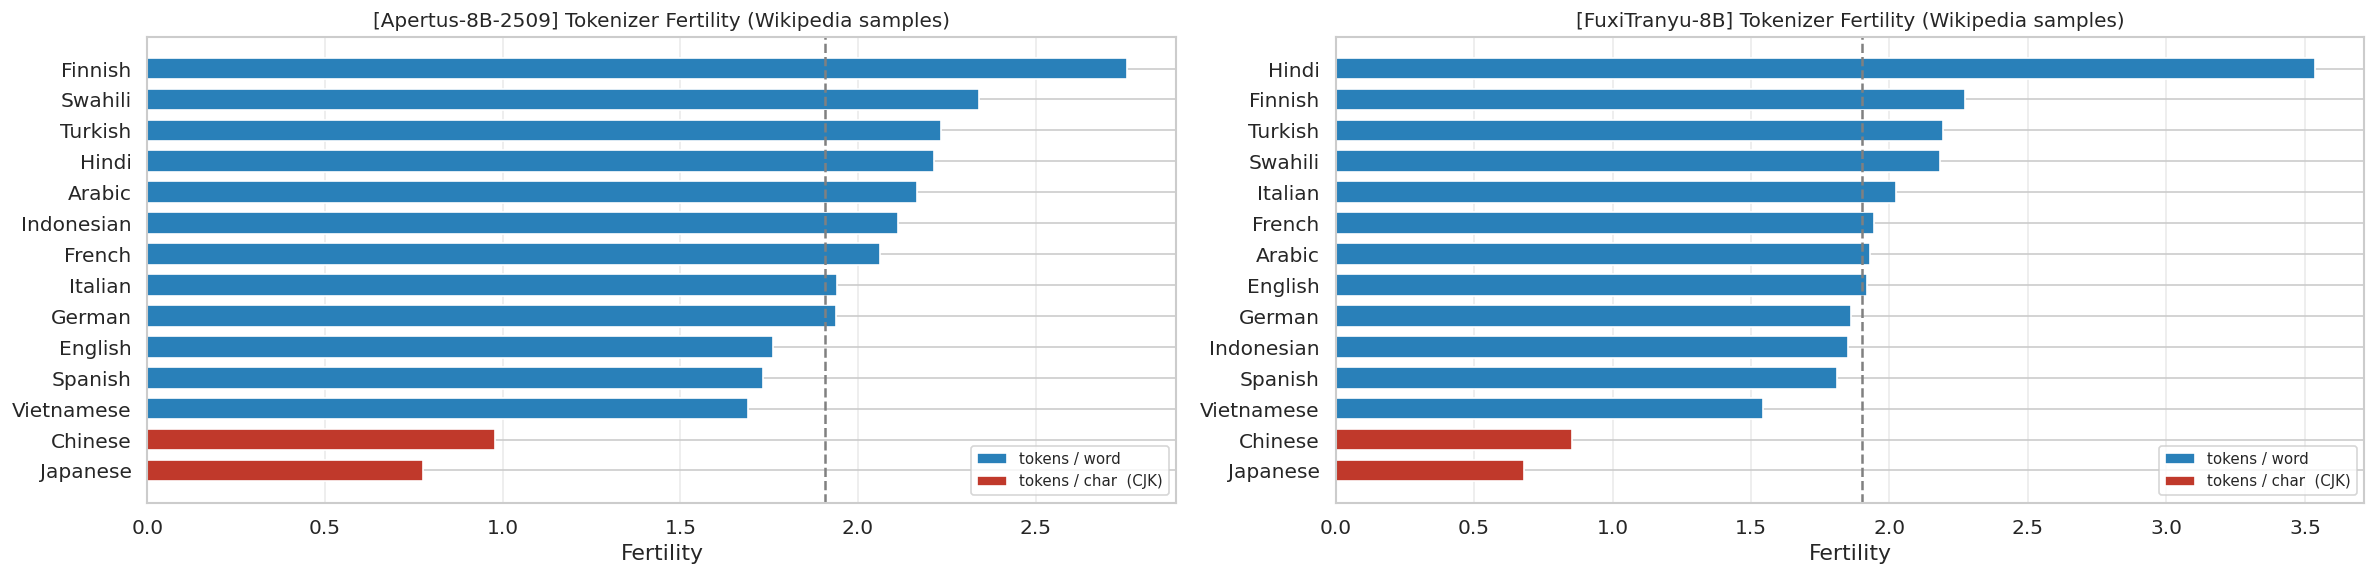

  language  fertility     unit
  Japanese     0.7764 tok/char
   Chinese     0.9773 tok/char
Vietnamese     1.6912 tok/word
   Spanish     1.7337 tok/word
   English     1.7603 tok/word
    German     1.9387 tok/word
   Italian     1.9415 tok/word
    French     2.0631 tok/word
Indonesian     2.1112 tok/word
    Arabic     2.1670 tok/word
     Hindi     2.2130 tok/word
   Turkish     2.2336 tok/word
   Swahili     2.3413 tok/word
   Finnish     2.7581 tok/word


In [8]:
df_fert = (
    pd.DataFrame({
        "language":  list(fertility.keys()),
        "fertility": list(fertility.values()),
        "unit":      [fert_unit[l] for l in fertility],
    })
    .sort_values("fertility").reset_index(drop=True)
)
common_langs = [l for l in df_fert.language if l in languages]

df_fert2 = None
if df2 is not None and fertility2:
    df_fert2 = (
        pd.DataFrame({
            "language":  list(fertility2.keys()),
            "fertility": list(fertility2.values()),
            "unit":      [fert_unit2.get(l, "tok/word") for l in fertility2],
        })
        .sort_values("fertility").reset_index(drop=True)
    )

plots = [(MODEL_LABEL, df_fert, fert_unit)]
if df_fert2 is not None:
    plots.append((COMPARE_LABEL, df_fert2, fert_unit2))

fig, axes = plt.subplots(1, len(plots), figsize=(10 * len(plots), 5))
axes = [axes] if len(plots) == 1 else list(axes)

for ax, (label, df_f, fert_u) in zip(axes, plots):
    colors = ["#c0392b" if fert_u.get(lang) == "tok/char" else "#2980b9" for lang in df_f.language]
    ax.barh(df_f.language, df_f.fertility, color=colors, height=0.7, edgecolor="white")
    ax.axvline(df_f.fertility.mean(), ls="--", color="gray", lw=1.5,
               label=f"Mean = {df_f.fertility.mean():.2f}")
    ax.set_xlabel("Fertility")
    ax.set_title(f"[{label}] Tokenizer Fertility (Wikipedia samples)", fontsize=12)
    ax.legend(handles=[
        Patch(facecolor="#2980b9", label="tokens / word"),
        Patch(facecolor="#c0392b", label="tokens / char  (CJK)"),
    ], loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/fertility_bar_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print(df_fert.to_string(index=False))


### 1b. Vocabulary Coverage

For each language we count how many **distinct token IDs** appear across the N sampled Wikipedia articles — i.e. what fraction of the full vocabulary the language actually activates.

- A **high-coverage** language touches many corners of the token space, suggesting broad lexical variety or a rich character combination space.
- A **low-coverage** language reuses a small, concentrated token subset — possibly because the tokenizer is well-matched to it (e.g. English) or because its writing system uses a small character set.

Coverage and fertility are complementary measurements:
- **Fertility** measures *density*: tokens per word — how fragmented encoding is for each text fragment.
- **Coverage** measures *breadth*: which tokens are used — how diverse the token distribution is across the corpus sample.

> **Note:** Coverage values require `COMPUTE=True` in the cluster cell above. The chart below will be empty if that block has not been run.

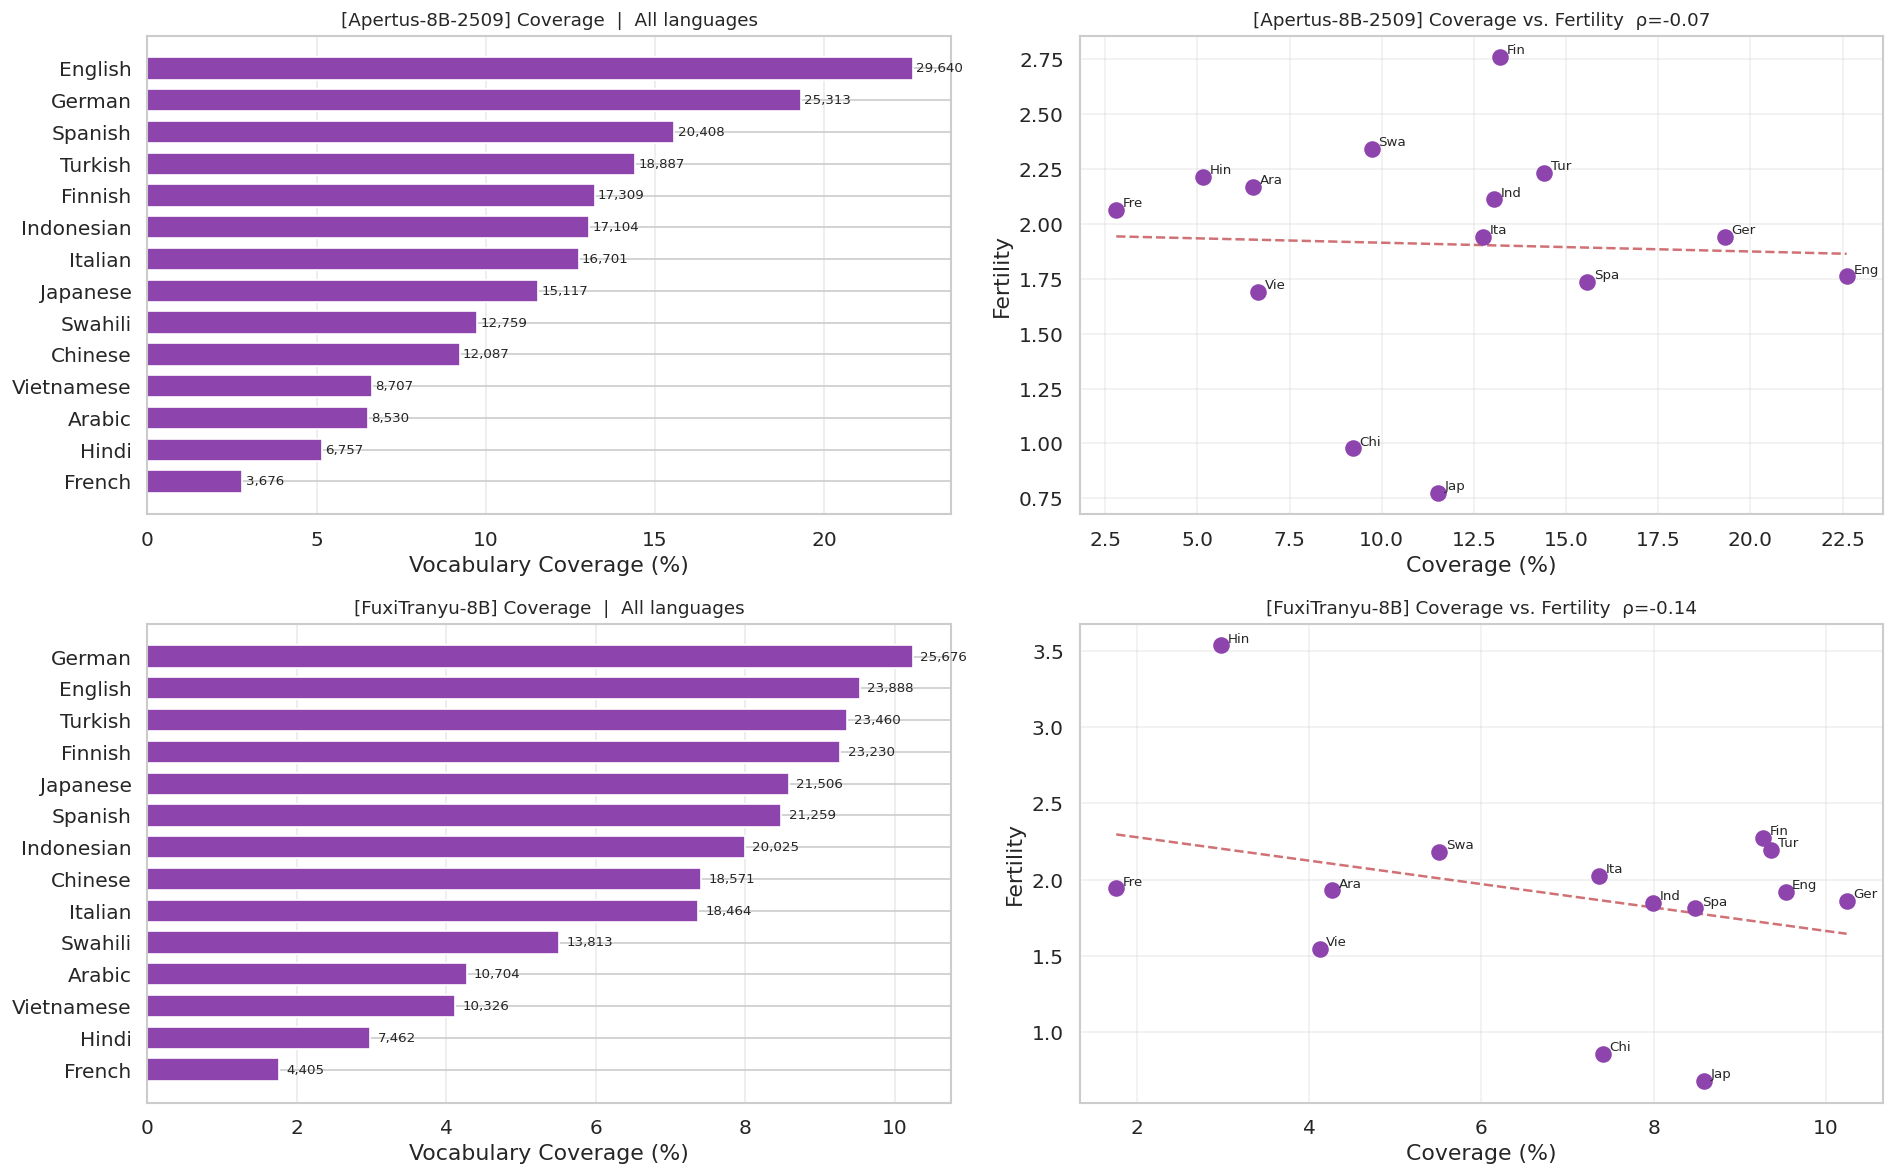

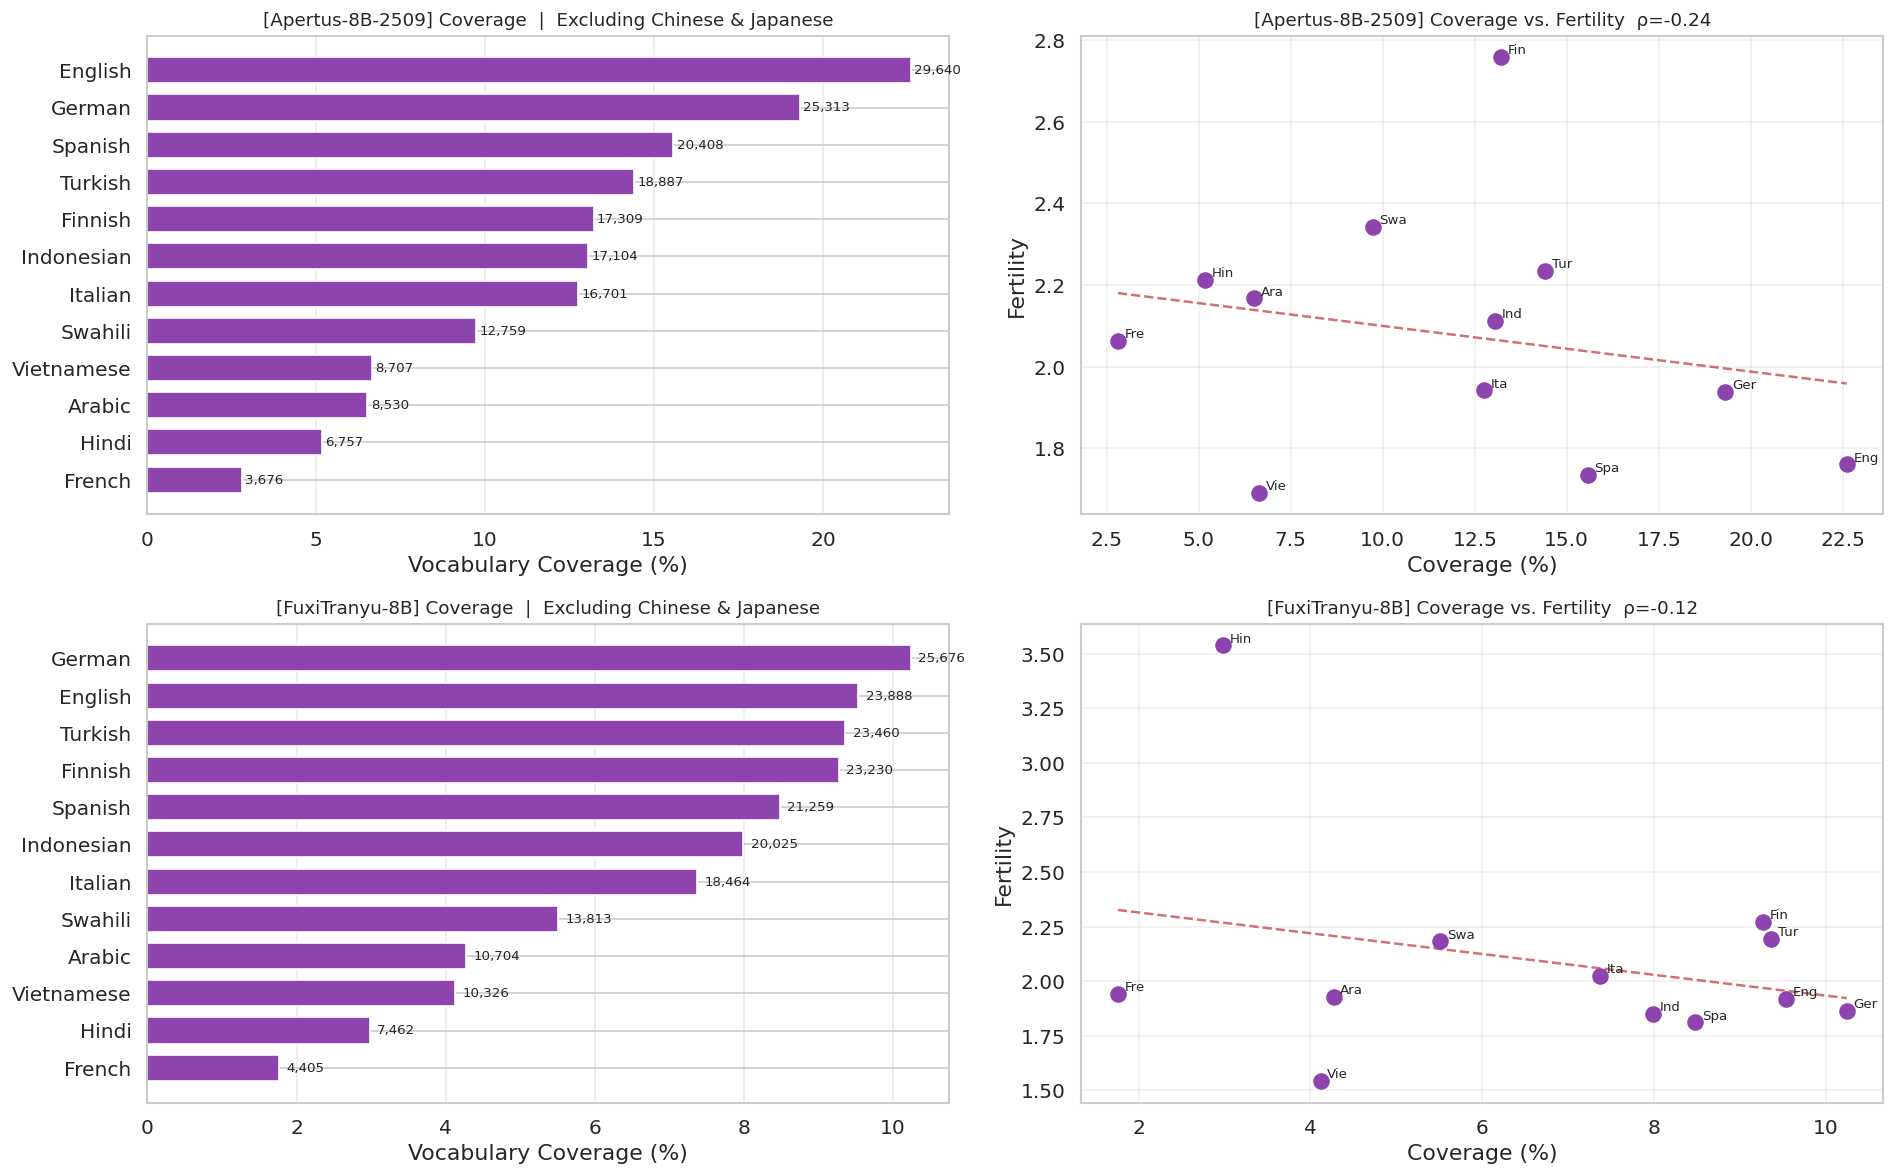

  language  coverage_pct  coverage_count
    French          2.80            3676
     Hindi          5.16            6757
    Arabic          6.51            8530
Vietnamese          6.64            8707
   Chinese          9.22           12087
   Swahili          9.73           12759
  Japanese         11.53           15117
   Italian         12.74           16701
Indonesian         13.05           17104
   Finnish         13.21           17309
   Turkish         14.41           18887
   Spanish         15.57           20408
    German         19.31           25313
   English         22.61           29640


In [9]:
if not vocab_coverage_pct:
    print("No coverage data — run COMPUTE block with COMPUTE=True.")
else:
    cov_df = (
        pd.DataFrame({
            "language":       list(vocab_coverage_pct.keys()),
            "coverage_pct":   list(vocab_coverage_pct.values()),
            "coverage_count": [vocab_coverage_count[l] for l in vocab_coverage_pct],
        })
        .sort_values("coverage_pct").reset_index(drop=True)
    )
    has_cmp = df2 is not None and bool(vocab_coverage_pct2)
    if has_cmp:
        cov_df2 = (
            pd.DataFrame({
                "language":       list(vocab_coverage_pct2.keys()),
                "coverage_pct":   list(vocab_coverage_pct2.values()),
                "coverage_count": [vocab_coverage_count2[l] for l in vocab_coverage_pct2],
            })
            .sort_values("coverage_pct").reset_index(drop=True)
        )

    CJK_LANGS = {"Chinese", "Japanese"}
    for subset_label, excl, suffix in [
        ("All languages",                set(),      "_all"),
        ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
    ]:
        rows_data = [(MODEL_LABEL, cov_df, fertility, fert_unit, vocab_coverage_pct)]
        if has_cmp:
            rows_data.append((COMPARE_LABEL, cov_df2, fertility2, fert_unit2, vocab_coverage_pct2))

        fig, axes = plt.subplots(len(rows_data), 2, figsize=(16, 5 * len(rows_data)))
        axes = axes.reshape(len(rows_data), 2)

        for row, (label, cov_d, fert, fert_u, cov_pct) in enumerate(rows_data):
            sub = cov_d[~cov_d.language.isin(excl)].reset_index(drop=True)
            ax = axes[row, 0]
            ax.barh(sub.language, sub.coverage_pct, color="#8e44ad", height=0.7, edgecolor="white")
            ax.set_xlabel("Vocabulary Coverage (%)")
            ax.set_title(f"[{label}] Coverage  |  {subset_label}", fontsize=11)
            ax.grid(axis="x", alpha=0.4)
            for i, r in sub.iterrows():
                ax.text(r.coverage_pct + 0.1, i, f"{int(r.coverage_count):,}", va="center", fontsize=8)

            ax = axes[row, 1]
            cov_langs = [l for l in cov_pct if l in fert and l not in excl]
            xs = np.array([cov_pct[l] for l in cov_langs])
            ys = np.array([fert[l]     for l in cov_langs])
            ax.scatter(xs, ys, s=80, color="#8e44ad", zorder=3)
            for x, y, lab in zip(xs, ys, cov_langs):
                ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=8)
            if len(xs) >= 3:
                z = np.polyfit(xs, ys, 1)
                xfit = np.linspace(xs.min(), xs.max(), 80)
                ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)
                rho_cf, _ = spearmanr(xs, ys)
                ax.set_title(f"[{label}] Coverage vs. Fertility  ρ={rho_cf:.2f}", fontsize=11)
            ax.set_xlabel("Coverage (%)"); ax.set_ylabel("Fertility")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"{STATIC_DIR}/vocab_coverage_{MODEL_LABEL}{suffix}.png", dpi=150, bbox_inches="tight")
        plt.show()
    print(cov_df.to_string(index=False))


## 2. RankMe at the Final Checkpoint

We examine the RankMe layer profile for each language at the final training checkpoint (`main`), using the **last-token** aggregation.

Lines are colored by fertility (low = bright, high = dark), so visual clusters immediately reveal whether fertility tracks RankMe level.

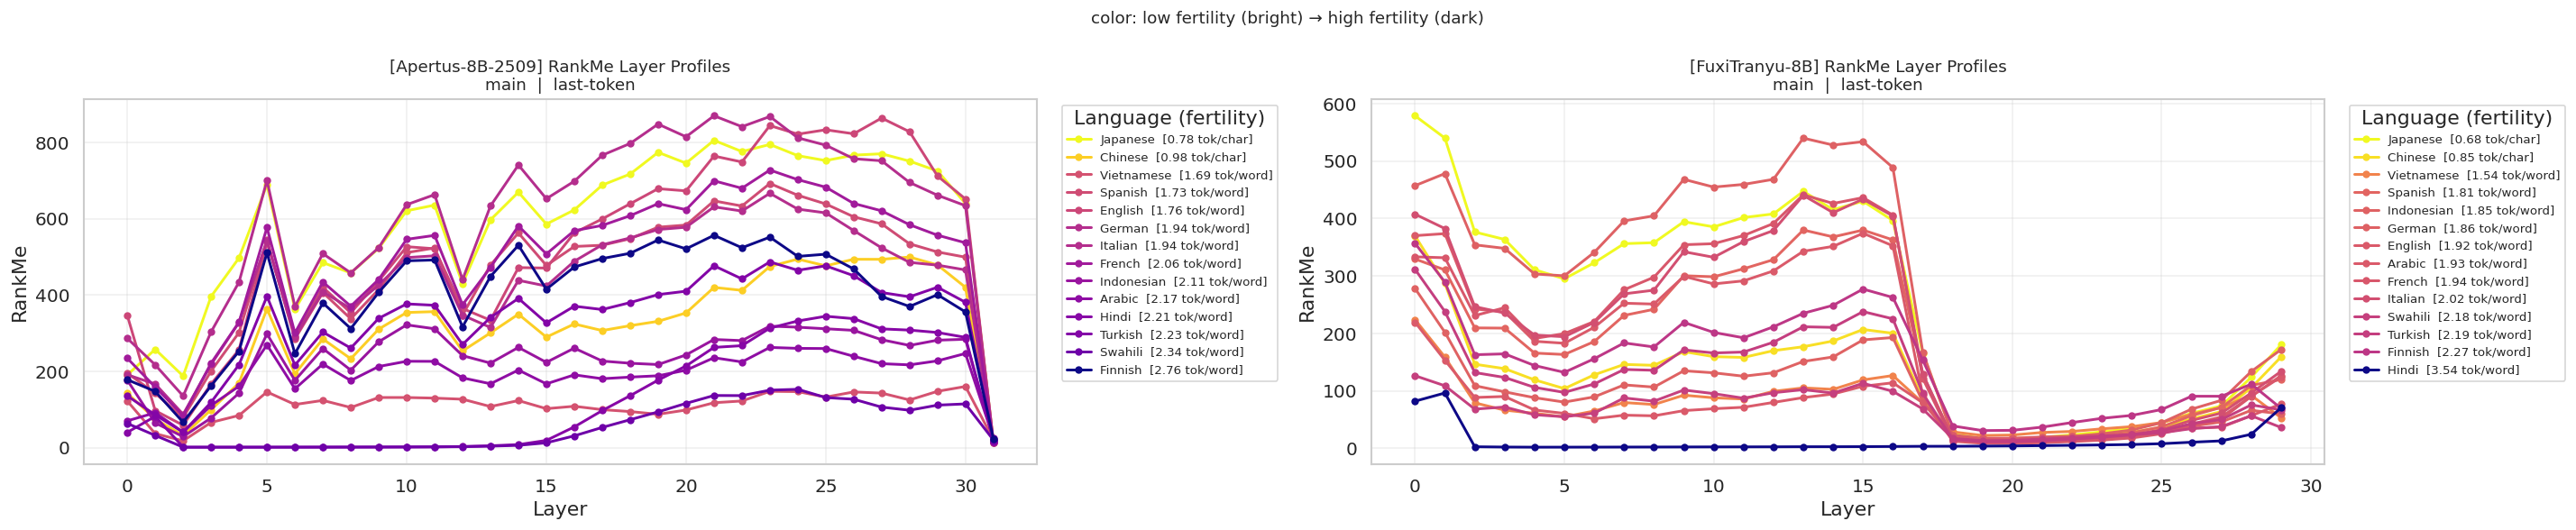

In [11]:
FINAL_CKPT = "main" if "main" in checkpoints else checkpoints[-1]
df_final = df_last[df_last.checkpoint == FINAL_CKPT]

plots = [(MODEL_LABEL, df_final, fertility, fert_unit, layers, layer_nums, common_langs, FINAL_CKPT)]
if df2 is not None:
    plots.append((COMPARE_LABEL, df2_final, fertility2, fert_unit2, layers2, layer_nums2, common_langs2, FINAL_CKPT2))

fig, axes = plt.subplots(1, len(plots), figsize=(12 * len(plots), 5))
axes = [axes] if len(plots) == 1 else list(axes)

for ax, (label, df_fin, fert, fert_u, lyrs, lnums, c_langs, final_ckpt) in zip(axes, plots):
    c_langs_f = [l for l in c_langs if l in fert]
    if not c_langs_f:
        ax.set_title(f"[{label}](no fertility data)"); continue
    fvals = [fert[l] for l in c_langs_f]
    fmin, fmax = min(fvals), max(fvals)
    cmap = plt.cm.plasma_r
    for lang in sorted(c_langs_f, key=lambda l: fert[l]):
        sub = df_fin[df_fin.dataset == lang].sort_values("layer", key=lambda s: s.map(layer_num))
        if sub.empty: continue
        f = fert[lang]
        ax.plot(sub.layer.map(layer_num), sub.rankme, marker="o", ms=4, lw=1.8,
                color=cmap((f - fmin) / (fmax - fmin + 1e-9)),
                label=f"{lang}  [{f:.2f} {fert_u.get(lang, '')}]")
    ax.set_xlabel("Layer"); ax.set_ylabel("RankMe")
    ax.set_title(f"[{label}] RankMe Layer Profiles\n{final_ckpt}  |  last-token", fontsize=11)
    ax.legend(title="Language (fertility)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("color: low fertility (bright) \u2192 high fertility (dark)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/layer_profiles_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Fertility–RankMe Correlation

For each layer at the final checkpoint, we compute Pearson $r$ and Spearman $\rho$ between fertility and RankMe across the languages present in the results.

> **Caveat:** With only 14 data points the correlation estimates carry wide confidence intervals. The analysis should be read as exploratory — we look for consistent directional trends across layers rather than individually significant p-values.

### 3a. Scatter Plots at Selected Layers

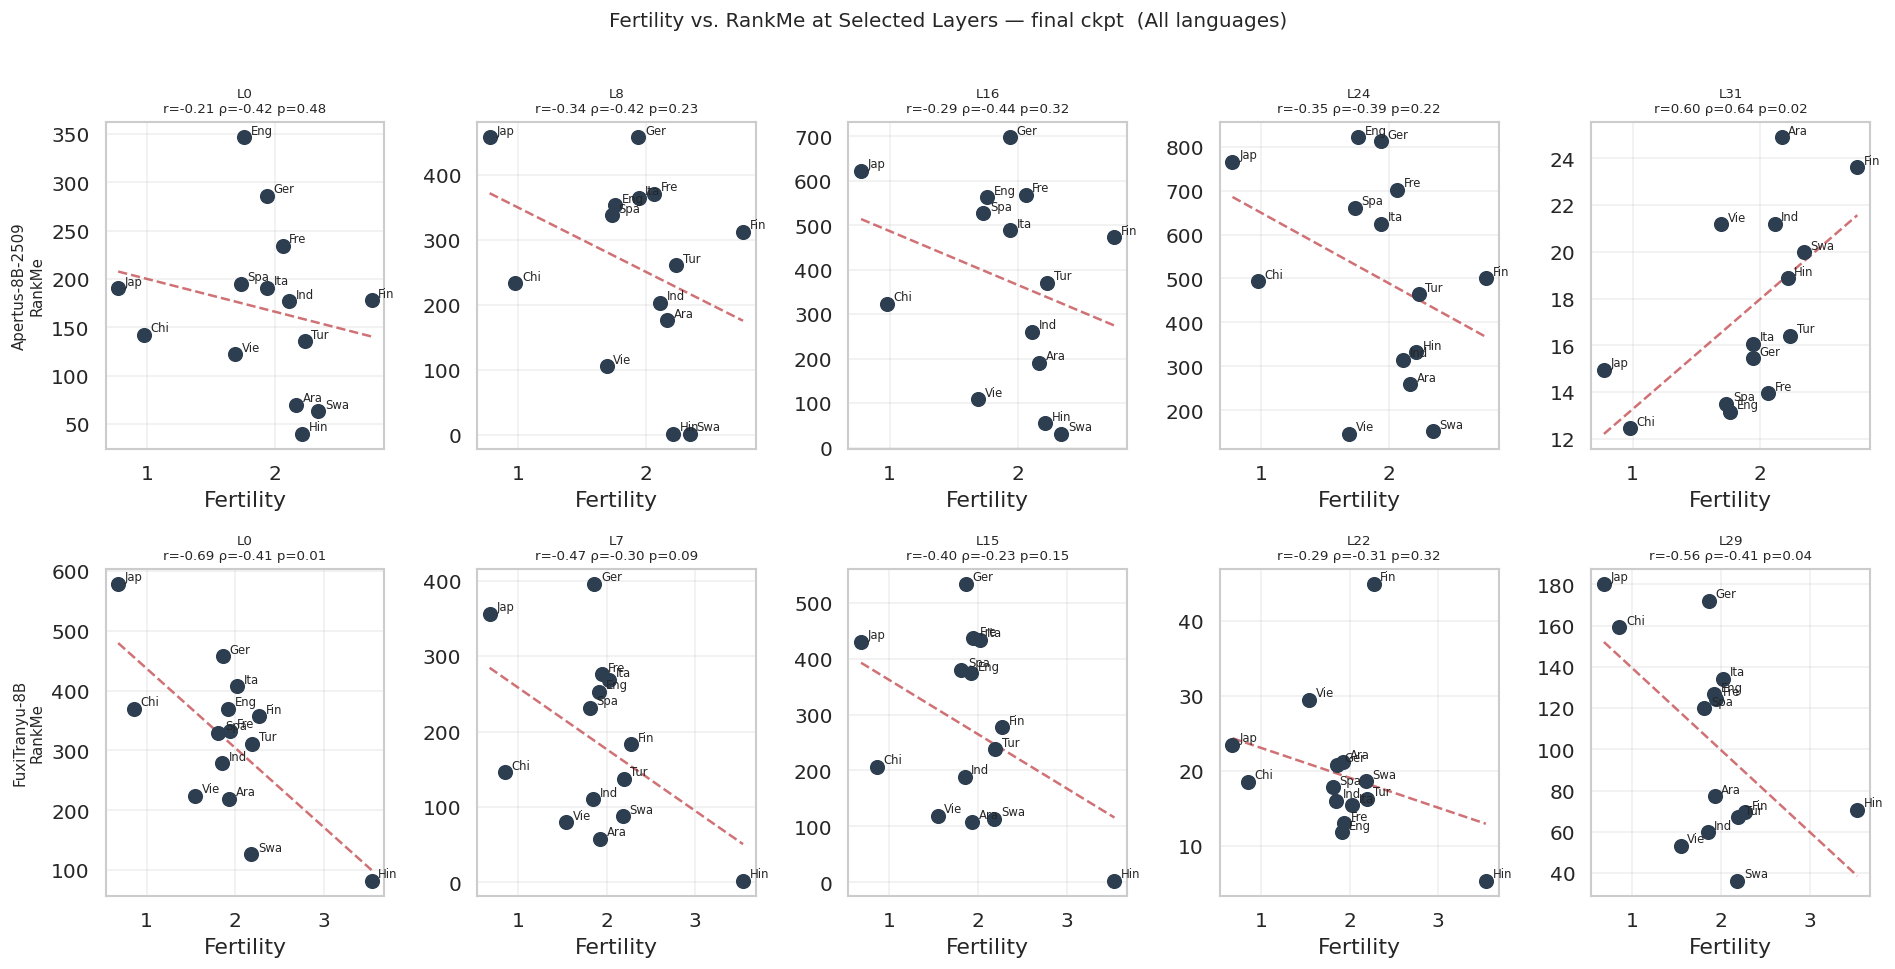

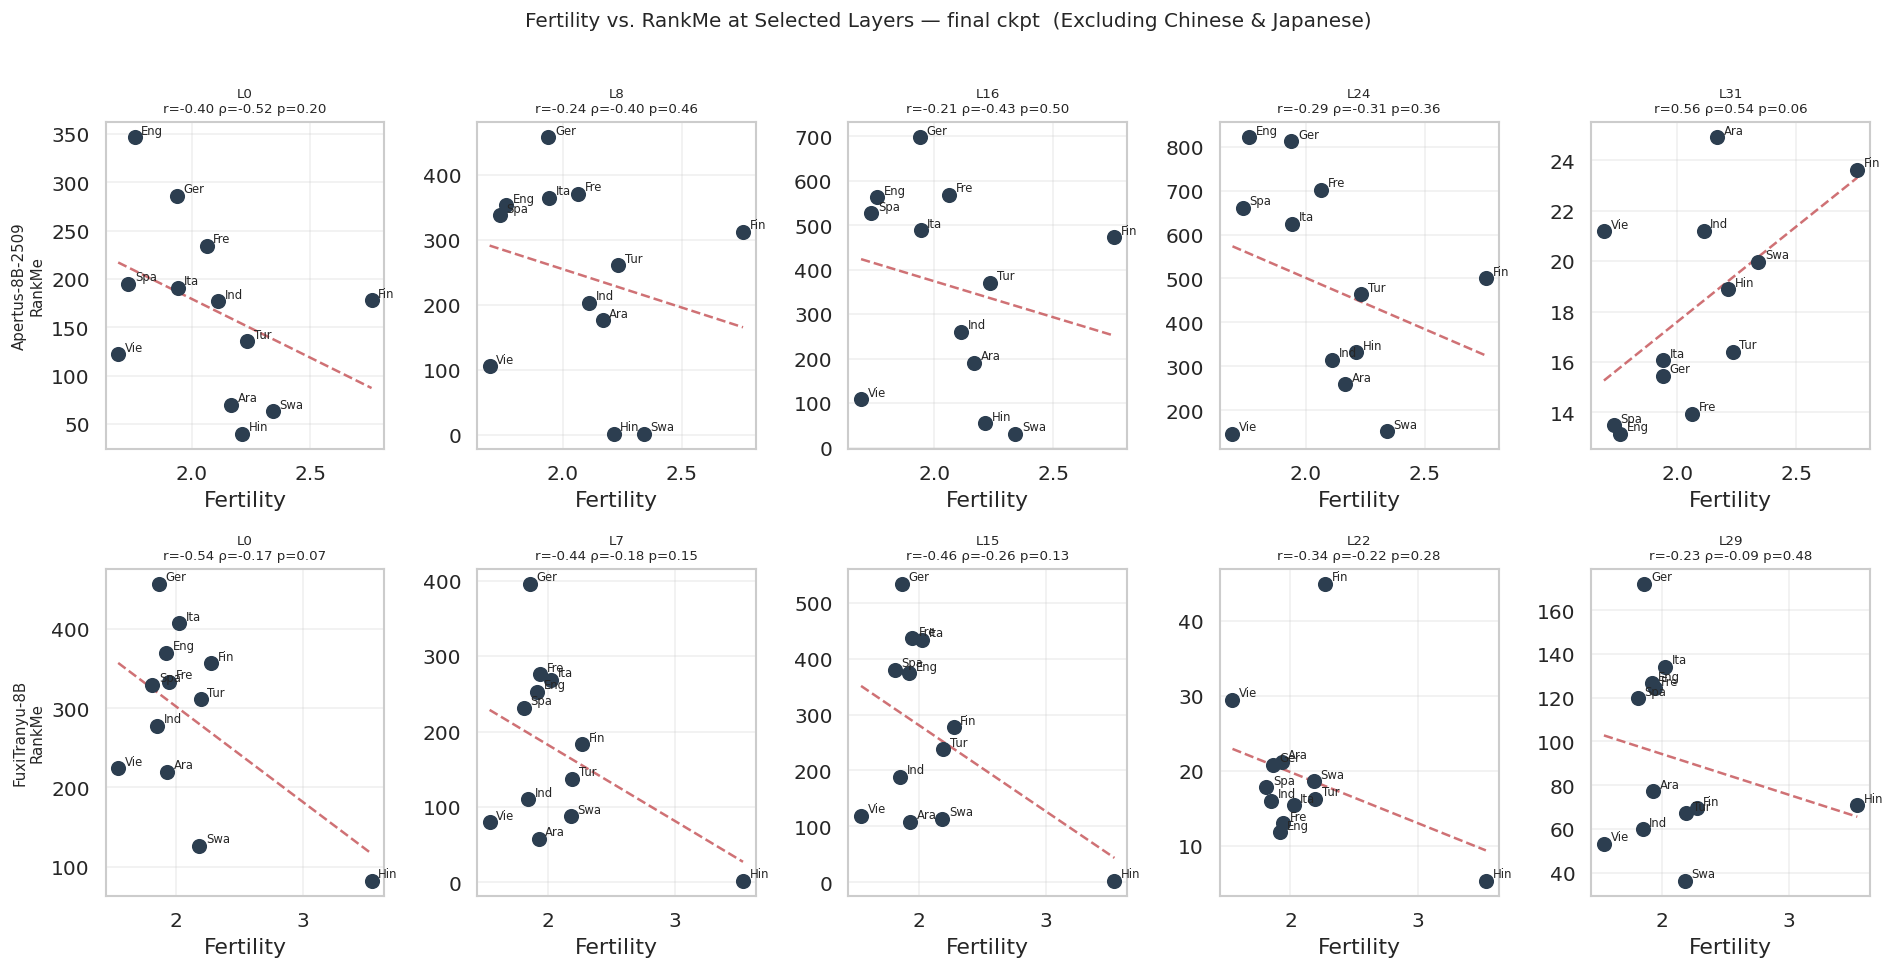

In [12]:
CJK_LANGS = {"Chinese", "Japanese"}
n = len(layers)
sel_layers = [layers[0], layers[n // 4], layers[n // 2], layers[3 * n // 4], layers[-1]]

_mdata = [(MODEL_LABEL, df_final, fertility, common_langs, sel_layers)]
if df2 is not None:
    n2 = len(layers2)
    sel2 = [layers2[0], layers2[n2 // 4], layers2[n2 // 2], layers2[3 * n2 // 4], layers2[-1]]
    _mdata.append((COMPARE_LABEL, df2_final, fertility2, common_langs2, sel2))

for subset_label, excl, suffix in [
    ("All languages",                set(),      "_all"),
    ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
]:
    n_rows, n_cols = len(_mdata), 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for row, (label, df_fin, fert, c_langs, s_layers) in enumerate(_mdata):
        langs_sub = [l for l in c_langs if l not in excl and l in fert]
        for col, layer in enumerate(s_layers):
            ax = axes[row, col]
            sub = df_fin[df_fin.layer == layer]
            xs, ys, labs = [], [], []
            for lang in langs_sub:
                r = sub[sub.dataset == lang]
                if not r.empty:
                    xs.append(fert[lang]); ys.append(r.rankme.values[0]); labs.append(lang)
            xs, ys = np.array(xs), np.array(ys)
            if len(xs) < 3:
                ax.set_title(f"L{layer_num(layer)}\n(no data)", fontsize=9); continue
            r_val, p = pearsonr(xs, ys)
            rho, _   = spearmanr(xs, ys)
            ax.scatter(xs, ys, s=65, color="#2c3e50", zorder=3)
            for x, y, lab in zip(xs, ys, labs):
                ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=7)
            z = np.polyfit(xs, ys, 1)
            xfit = np.linspace(xs.min(), xs.max(), 80)
            ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)
            ax.set_title(f"L{layer_num(layer)}\nr={r_val:.2f} \u03c1={rho:.2f} p={p:.2f}", fontsize=8)
            ax.set_xlabel("Fertility")
            if col == 0:
                ax.set_ylabel(f"{label}\nRankMe", fontsize=9)
            ax.grid(True, alpha=0.3)

    fig.suptitle(f"Fertility vs. RankMe at Selected Layers \u2014 final ckpt  ({subset_label})",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/scatter_fertility_rankme_{MODEL_LABEL}{suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Observations
Most layer correlations are not statistically significant ($p > 0.05$). However, a stark divergence emerges in the final layers of the two models. While all preceding layers exhibit a slight negative correlation across both models, Apertus displays a sharp shift to a statistically significant positive correlation in its very last layer (when including all languages). Conversely, Fuxi maintains a negative, statistically significant correlation through to its final layer. Given that we observe conflicting behaviors in the two models, it's impossible to derive a definitive conclusion that aims at explaining intuitively the observed behavior.

### 3b. Correlation Profile Across All Layers

The profile shows how tightly fertility and RankMe track each other as a function of depth.  
Gold bands mark layers where Pearson $r$ is statistically significant at $p < 0.05$.

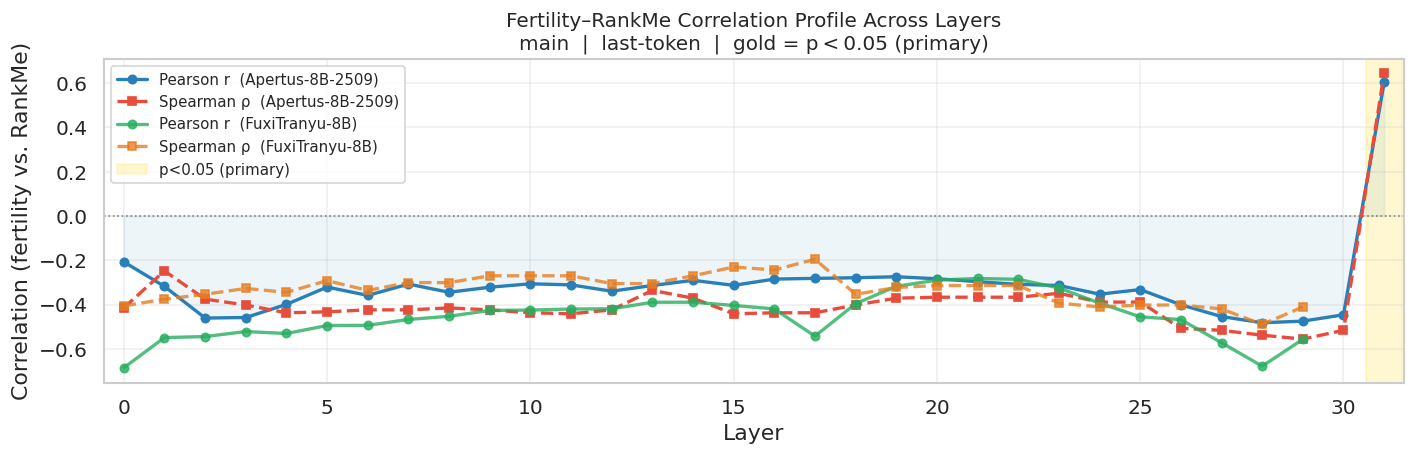

Layers |r|>0.5 (Apertus-8B-2509):
 layer  pearson_r  spearman_rho  p_value
    31   0.602452      0.643956 0.022604


In [13]:
prs, rhos, pvals = [], [], []
for layer in layers:
    sub = df_final[df_final.layer == layer]
    xs, ys = [], []
    for lang in common_langs:
        row = sub[sub.dataset == lang]
        if not row.empty:
            xs.append(fertility[lang]); ys.append(row.rankme.values[0])
    if len(xs) < 3:
        prs.append(np.nan); rhos.append(np.nan); pvals.append(np.nan); continue
    r, p = pearsonr(xs, ys); rho, _ = spearmanr(xs, ys)
    prs.append(r); rhos.append(rho); pvals.append(p)

prs2, rhos2, pvals2 = [], [], []
if df2 is not None and fertility2:
    for layer in layers2:
        sub = df2_final[df2_final.layer == layer]
        xs, ys = [], []
        for lang in common_langs2:
            row = sub[sub.dataset == lang]
            if not row.empty:
                xs.append(fertility2[lang]); ys.append(row.rankme.values[0])
        if len(xs) < 3:
            prs2.append(np.nan); rhos2.append(np.nan); pvals2.append(np.nan); continue
        r, p = pearsonr(xs, ys); rho, _ = spearmanr(xs, ys)
        prs2.append(r); rhos2.append(rho); pvals2.append(p)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(layer_nums, prs,  "o-",  color="#2980b9", lw=2, ms=5, label=f"Pearson r  ({MODEL_LABEL})")
ax.plot(layer_nums, rhos, "s--", color="#e74c3c", lw=2, ms=5, label=f"Spearman \u03c1  ({MODEL_LABEL})")
if prs2:
    ax.plot(layer_nums2, prs2,  "o-",  color="#27ae60", lw=2, ms=5, alpha=0.8,
            label=f"Pearson r  ({COMPARE_LABEL})")
    ax.plot(layer_nums2, rhos2, "s--", color="#e67e22", lw=2, ms=5, alpha=0.8,
            label=f"Spearman \u03c1  ({COMPARE_LABEL})")
ax.axhline(0, color="gray", lw=1, ls=":")
ax.fill_between(layer_nums, prs, 0, alpha=0.08, color="#2980b9")
sig_added = False
for lnum, p in zip(layer_nums, pvals):
    if p is not None and not np.isnan(p) and p < 0.05:
        ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.18, color="gold", zorder=0,
                   label="p<0.05 (primary)" if not sig_added else None)
        sig_added = True
ax.set_xlabel("Layer")
ax.set_ylabel("Correlation (fertility vs. RankMe)")
ax.set_title(
    f"Fertility\u2013RankMe Correlation Profile Across Layers\n"
    f"{FINAL_CKPT}  |  last-token  |  gold = p\u202f<\u202f0.05 (primary)",
    fontsize=12,
)
ax.legend(fontsize=9)
max_lnum = max(layer_nums[-1], layer_nums2[-1] if prs2 else 0)
ax.set_xlim(-0.5, max_lnum + 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/correlation_profile_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

df_corr = pd.DataFrame({"layer": layer_nums, "pearson_r": prs, "spearman_rho": rhos, "p_value": pvals})
print(f"Layers |r|>0.5 ({MODEL_LABEL}):")
print(df_corr[df_corr.pearson_r.abs() > 0.5].to_string(index=False))


### 3c. Coverage–RankMe Correlation Profile

We repeat the layer-by-layer Spearman rank correlation analysis, substituting **vocabulary coverage** for fertility. Overlaying both curves reveals whether coverage adds independent predictive power:

- If the curves **track each other**, fertility and coverage carry the same signal — one redundant with the other.
- If they **diverge** at certain layers, coverage captures a distinct geometric signature (e.g. breadth of token usage may matter more in middle layers than density).

> **Note:** This section requires vocabulary coverage data from the COMPUTE block above.

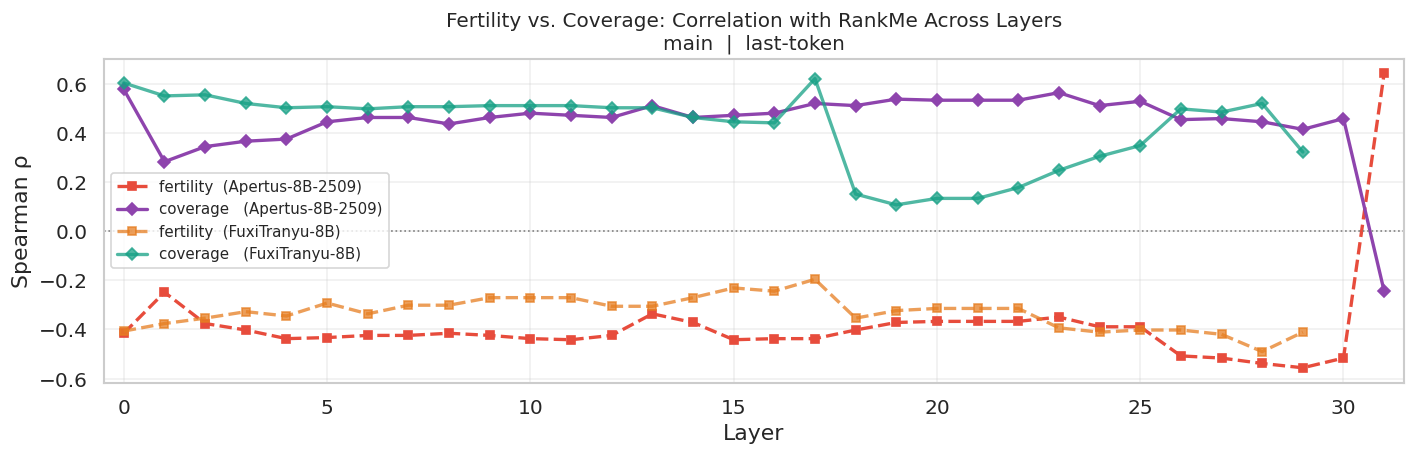

In [14]:
if not vocab_coverage_pct:
    print("No coverage data — run COMPUTE block.")
else:
    cov_rhos, cov_rhos2 = [], []
    for layer in layers:
        sub = df_final[df_final.layer == layer]
        xs_c, ys_r = [], []
        for lang in [l for l in common_langs if l in vocab_coverage_pct]:
            row = sub[sub.dataset == lang]
            if not row.empty:
                xs_c.append(vocab_coverage_pct[lang]); ys_r.append(row.rankme.values[0])
        if len(xs_c) < 3:
            cov_rhos.append(np.nan); continue
        rho, _ = spearmanr(xs_c, ys_r); cov_rhos.append(rho)

    if df2 is not None and vocab_coverage_pct2:
        for layer in layers2:
            sub = df2_final[df2_final.layer == layer]
            xs_c, ys_r = [], []
            for lang in [l for l in common_langs2 if l in vocab_coverage_pct2]:
                row = sub[sub.dataset == lang]
                if not row.empty:
                    xs_c.append(vocab_coverage_pct2[lang]); ys_r.append(row.rankme.values[0])
            if len(xs_c) < 3:
                cov_rhos2.append(np.nan); continue
            rho, _ = spearmanr(xs_c, ys_r); cov_rhos2.append(rho)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(layer_nums, rhos,     "s--", color="#e74c3c", lw=2, ms=5,
            label=f"fertility  ({MODEL_LABEL})")
    ax.plot(layer_nums, cov_rhos, "D-",  color="#8e44ad", lw=2, ms=5,
            label=f"coverage   ({MODEL_LABEL})")
    if rhos2:
        ax.plot(layer_nums2, rhos2,     "s--", color="#e67e22", lw=2, ms=5, alpha=0.75,
                label=f"fertility  ({COMPARE_LABEL})")
    if cov_rhos2:
        ax.plot(layer_nums2, cov_rhos2, "D-",  color="#16a085", lw=2, ms=5, alpha=0.75,
                label=f"coverage   ({COMPARE_LABEL})")
    ax.axhline(0, color="gray", lw=1, ls=":")
    ax.set_xlabel("Layer"); ax.set_ylabel("Spearman \u03c1")
    ax.set_title(
        f"Fertility vs. Coverage: Correlation with RankMe Across Layers\n"
        f"{FINAL_CKPT}  |  last-token", fontsize=12)
    ax.legend(fontsize=9)
    max_lnum = max(layer_nums[-1], layer_nums2[-1] if (rhos2 or cov_rhos2) else 0)
    ax.set_xlim(-0.5, max_lnum + 0.5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/coverage_vs_fertility_corr_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4. Training Dynamics by Fertility Tier

We split the languages into three equal-sized fertility tiers (low / medium / high) and track mean RankMe over training at the **middle layer** — the depth where the most active learning of linguistic structure typically occurs.

A widening gap between tiers during training would confirm H3: the model learns more effective representations for low-fertility languages more quickly.

Low: ['Japanese', 'Chinese', 'Vietnamese', 'Spanish']   Mid: ['English', 'German', 'Italian', 'French']   High: ['Indonesian', 'Arabic', 'Hindi', 'Turkish', 'Swahili', 'Finnish']


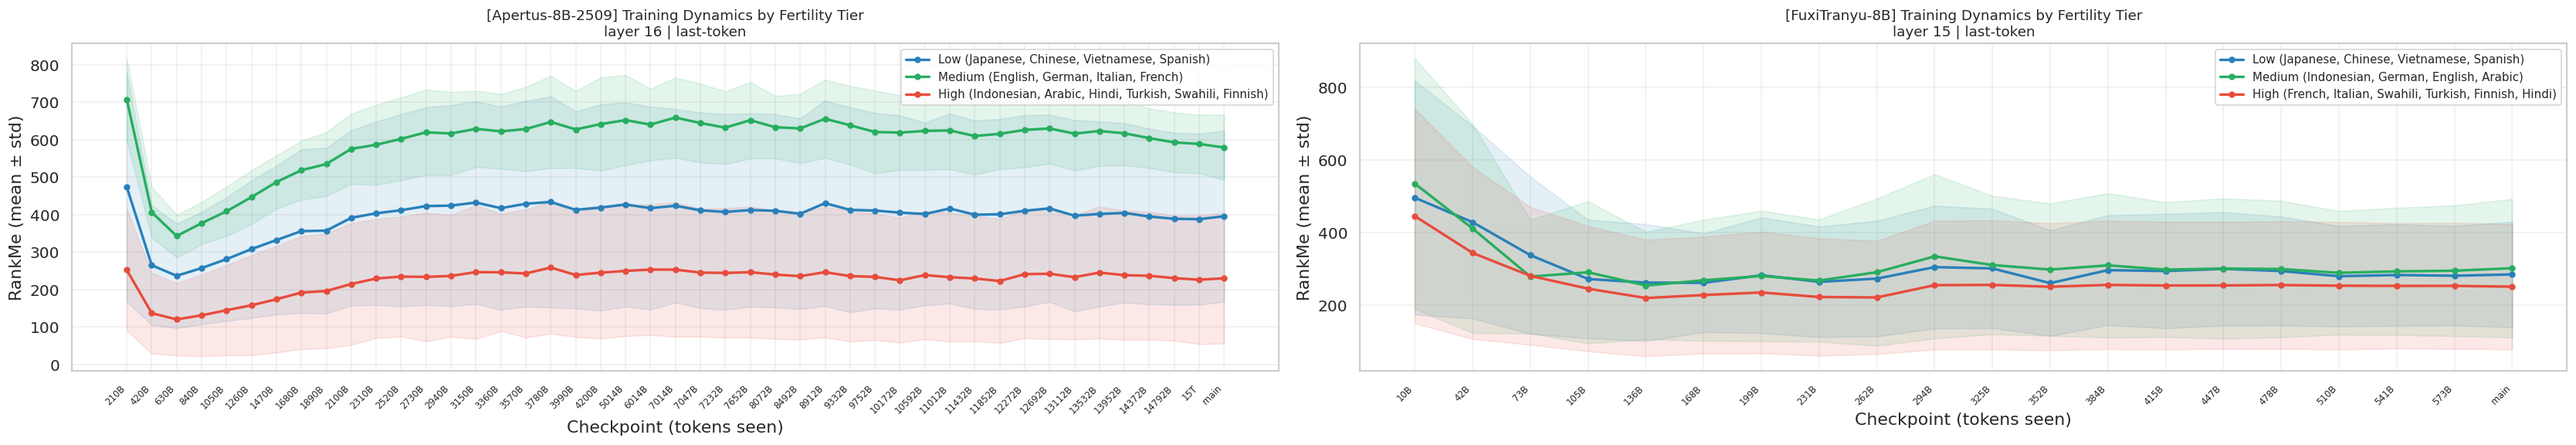

In [15]:
df_fert_sorted = df_fert[df_fert.language.isin(common_langs)].sort_values("fertility").reset_index(drop=True)
k = max(1, len(df_fert_sorted) // 3)
low_tier  = df_fert_sorted.iloc[:k].language.tolist()
mid_tier  = df_fert_sorted.iloc[k:2*k].language.tolist()
high_tier = df_fert_sorted.iloc[2*k:].language.tolist()
print("Low:", low_tier, "  Mid:", mid_tier, "  High:", high_tier)

TIERS1 = {"Low": (low_tier, "#2980b9"), "Medium": (mid_tier, "#27ae60"), "High": (high_tier, "#e74c3c")}

def _tier_plot(ax, label, df_l, lyrs, ckpts, ckpt_labs, tiers):
    mid_layer = lyrs[len(lyrs) // 2]
    df_mid = df_l[df_l.layer == mid_layer]
    for tname, (langs, color) in tiers.items():
        records = []
        for ci, ckpt in enumerate(ckpts):
            sub = df_mid[(df_mid.checkpoint == ckpt) & (df_mid.dataset.isin(langs))]
            if not sub.empty:
                records.append({"idx": ci, "mean": sub.rankme.mean(), "std": sub.rankme.std()})
        if not records: continue
        tr = pd.DataFrame(records).sort_values("idx")
        xs, ys = tr.idx.values, tr["mean"].values
        ax.plot(xs, ys, "o-", color=color, lw=2, ms=4, label=f"{tname} ({', '.join(langs)})")
        ax.fill_between(xs, ys - tr["std"].values, ys + tr["std"].values, alpha=0.12, color=color)
    ax.set_xticks(range(len(ckpts)))
    ax.set_xticklabels(ckpt_labs, rotation=45, ha="right", fontsize=7)
    ax.set_xlabel("Checkpoint (tokens seen)"); ax.set_ylabel("RankMe (mean \u00b1 std)")
    ax.set_title(f"[{label}] Training Dynamics by Fertility Tier\nlayer {layer_num(mid_layer)} | last-token", fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

n_cols = 2 if (df2 is not None and df_fert2 is not None) else 1
fig, axes = plt.subplots(1, n_cols, figsize=(14 * n_cols, 5))
axes = [axes] if n_cols == 1 else list(axes)
_tier_plot(axes[0], MODEL_LABEL, df_last, layers, checkpoints, ckpt_labels, TIERS1)

if n_cols == 2:
    df_f2s = df_fert2[df_fert2.language.isin(common_langs2)].sort_values("fertility").reset_index(drop=True)
    k2 = max(1, len(df_f2s) // 3)
    TIERS2 = {
        "Low":    (df_f2s.iloc[:k2].language.tolist(),     "#2980b9"),
        "Medium": (df_f2s.iloc[k2:2*k2].language.tolist(), "#27ae60"),
        "High":   (df_f2s.iloc[2*k2:].language.tolist(),   "#e74c3c"),
    }
    _tier_plot(axes[1], COMPARE_LABEL, df2_last, layers2, checkpoints2, ckpt_labels2, TIERS2)

plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/training_dynamics_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


### 4b. Spearman ρ Heatmap — All Checkpoints × All Layers

Each cell shows the Spearman rank correlation between fertility and RankMe across the languages for a given (checkpoint, layer) pair.

- **Blue**: higher fertility → lower RankMe (fragmented tokens lead to more degenerate geometry)  
- **Red**: higher fertility → higher RankMe (model compensates with richer representations)  
- **White**: no correlation

This view reveals *when* and *where* in the network the fertility signal emerges during training.

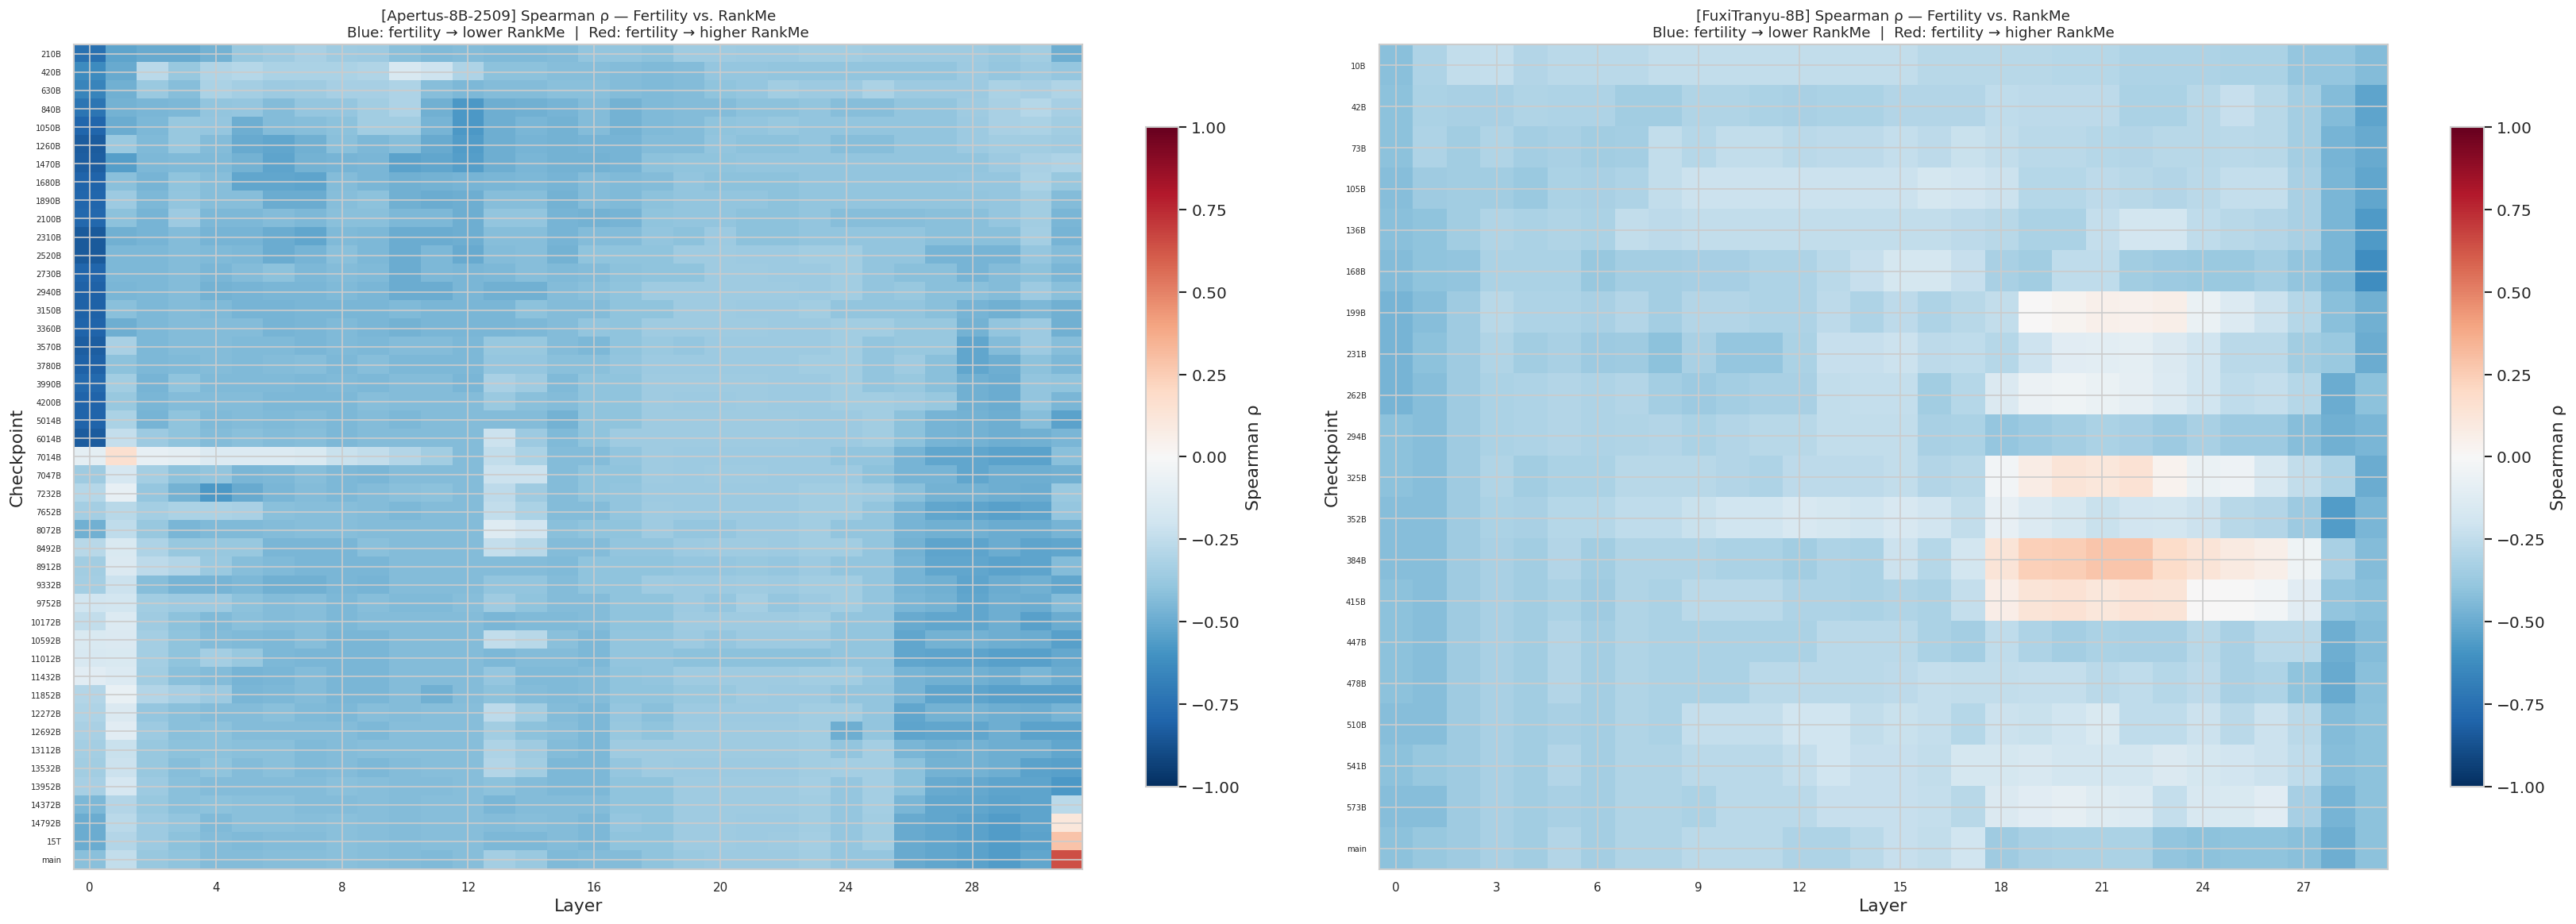

Mean ρ (Apertus-8B-2509): -0.414
Mean ρ (FuxiTranyu-8B): -0.279


In [16]:
def _rho_mat(df_l, fert, langs, ckpts, lyrs):
    mat = np.full((len(ckpts), len(lyrs)), np.nan)
    for ci, ckpt in enumerate(ckpts):
        for li, layer in enumerate(lyrs):
            sub = df_l[(df_l.checkpoint == ckpt) & (df_l.layer == layer)]
            xs, ys = [], []
            for lang in langs:
                row = sub[sub.dataset == lang]
                if not row.empty:
                    xs.append(fert[lang]); ys.append(row.rankme.values[0])
            if len(xs) >= 3:
                rho, _ = spearmanr(xs, ys); mat[ci, li] = rho
    return mat

mat1 = _rho_mat(df_last, fertility, [l for l in common_langs if l in fertility],
                checkpoints, layers)
mat2 = None
if df2 is not None and fertility2:
    mat2 = _rho_mat(df2_last, fertility2, [l for l in common_langs2 if l in fertility2],
                    checkpoints2, layers2)

panels = [(mat1, ckpt_labels, layer_nums, MODEL_LABEL)]
if mat2 is not None:
    panels.append((mat2, ckpt_labels2, layer_nums2, COMPARE_LABEL))

max_ckpts = max(len(p[1]) for p in panels)
fig, axes = plt.subplots(1, len(panels), figsize=(14 * len(panels), max(5, max_ckpts * 0.22)))
axes = [axes] if len(panels) == 1 else list(axes)

for ax, (mat, ckpt_labs, lnums, label) in zip(axes, panels):
    xtick_pos  = list(range(0, len(lnums), max(1, len(lnums) // 8)))
    xtick_labs = [lnums[i] for i in xtick_pos]
    im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
    plt.colorbar(im, ax=ax, label="Spearman \u03c1", shrink=0.8)
    ax.set_xticks(xtick_pos); ax.set_xticklabels(xtick_labs, fontsize=9)
    ax.set_yticks(range(len(ckpt_labs))); ax.set_yticklabels(ckpt_labs, fontsize=6)
    ax.set_xlabel("Layer"); ax.set_ylabel("Checkpoint")
    ax.set_title(
        f"[{label}] Spearman \u03c1 — Fertility vs. RankMe\n"
        "Blue: fertility \u2192 lower RankMe  |  Red: fertility \u2192 higher RankMe",
        fontsize=11)

plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/spearman_heatmap_{MODEL_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean \u03c1 ({MODEL_LABEL}): {np.nanmean(mat1):.3f}")
if mat2 is not None:
    print(f"Mean \u03c1 ({COMPARE_LABEL}): {np.nanmean(mat2):.3f}")


## 5. Conclusions

### FuxiTranyu-8B
Statistically significant correlations ($p < 0.05$) between fertility and RankMe appear at the first and last few
layers, but not in the middle. We interpret this as a U-shaped depth profile: early layers still operate close to the
token surface, where the tokenizer's fragmentation directly shapes the representation; middle layers learn more
abstract, language-agnostic features where the fertility signal fades; and the final layers, tasked with projecting
back toward the token vocabulary, recover the correlation.

At the per-language level, no consistent pattern emerges that would support a stronger claim.

Overall, the correlation between fertility and RankMe is slightly negative across all layers and checkpoints,
suggesting that higher tokenizer fragmentation is associated with lower effective dimensionality in the
representations. However, with only 14 languages the statistical power is limited, and the results should be read as exploratory rather than definitive.
